# Práctica 2 - Visión por Computador
## Marcial Galván - Alejandra Rodríguez

### Tabla de contenidos
- [Tarea 1 - Bordes en Canny](#tarea-1---bordes-en-canny)
- [Tarea 2 - Comparativa entre Canny y Sobel umbralizado](#tarea-2---comparativa-entre-canny-y-sobel-umbralizado)
- [Tarea 3 - Demostraciones con procesamiento de imagen](#tarea-3---demostraciones-con-procesamiento-de-imagen)

### Tarea 1 - Bordes en Canny

Cálculo de bordes y análisis de resultados, destacando las filas con mayor número de bordes detectados.

In [76]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Para llevar a cabo esta tarea, primero se debe realizar el recuento de bordes detectados por fila. Para ello, se aplica Canny sobre la imagen del mandril en escala de grises y, a continuación, se cuenta el número de píxeles blancos por fila con `cv2.reduce`.

In [77]:
def row_counts(image):
    counts = cv2.reduce(image, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).reshape(-1)
    return counts / (255 * image.shape[1])

In [78]:
img = cv2.imread('exercises/mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)

rows = row_counts(canny)

Una vez realizado el recuento de bordes por fila, se pueden computar los siguientes parámetros:
- **`max_idx`**: índice de la fila con máximo recuento de píxeles blancos
- **`max90_idx`**: índices de filas cuyo recuento de píxeles blancos iguala o supera `0.9 × recuento[max_idx]`

In [79]:
def find_max_idx(rows):
    return np.argmax(rows)

def find_max90_idx(rows, max_idx):
    return np.where(rows >= 0.9 * rows[max_idx])[0]

Las filas identificadas por `max_idx` y `max90_idx`, con gran densidad de bordes detectados, se pueden resaltar gráficamente sobre la imagen de Canny. Por ejemplo, dibujando líneas (con transparencia) sobre ellas:

In [80]:
def draw_threshold(image, max_idx, threshold_idx, alpha=0.8):
    overlay = image.copy()
    for idx in threshold_idx:
        cv2.line(overlay, (0, idx), (image.shape[1], idx), (255, 255, 0), 1)
    cv2.line(overlay, (0, max_idx), (image.shape[1], max_idx), (255, 0, 0), 4)

    return cv2.addWeighted(overlay, alpha, image, 1-alpha, 0)

In [81]:
max_idx = find_max_idx(rows)
max90_idx = find_max90_idx(rows, max_idx)

canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

In [82]:
print(f"- Fila con más píxeles blancos detectados: {max_idx} ({rows[max_idx]:.2%})")
print(f"- Filas ≥ 90% del máximo ({len(max90_idx)}): {max90_idx}")

- Fila con más píxeles blancos detectados: 12 (42.97%)
- Filas ≥ 90% del máximo (7): [  6  12  15  20  21  88 100]


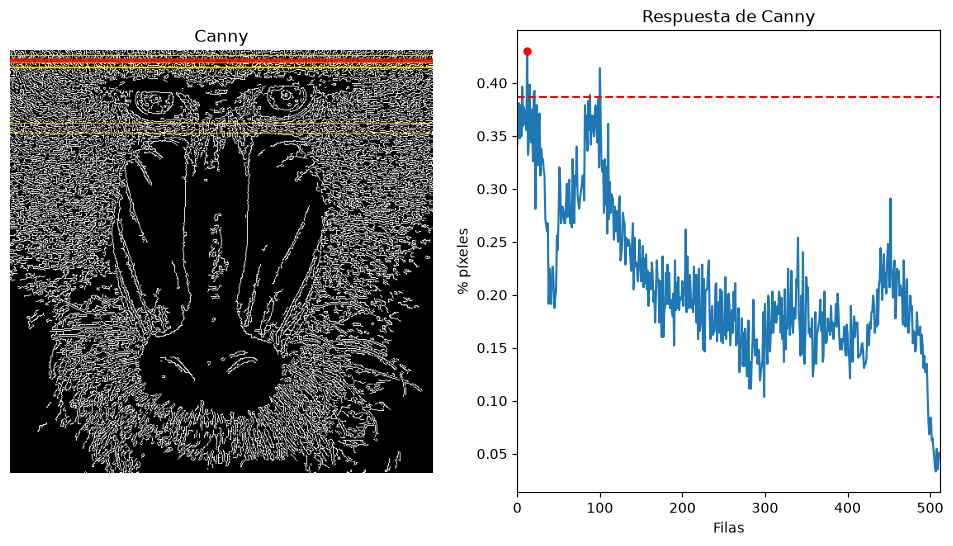

In [83]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(draw_threshold(canny_rgb, max_idx, max90_idx)) 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")

plt.plot(rows)
plt.plot(max_idx, rows[max_idx], 'o', markersize=5, color='red')
plt.axhline(y=0.9 * rows[max_idx], linestyle='--', color='red')
plt.xlim([0, canny.shape[0]])
plt.show()

Se aprecia que las filas con mayor textura (por ejemplo, en la parte superior de la cabeza) producen más bordes y, por tanto, más píxeles de color blanco.
<br><br>
Sin embargo, las zonas más homogéneas, como la parte inferior de la imagen, generan un menor número de bordes.

### Tarea 2 - Comparativa entre Canny y Sobel umbralizado

Aplicar umbralizado a la imagen de Sobel convertida a 8 bits, y comparar el conteo de filas y columnas (igual que el realizado en la [tarea 1](#tarea-1---bordes-en-canny)) con el obtenido sobre la imagen de Canny.

In [105]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Para realizar esta tarea, se recuperan el conteo, la búsqueda de máximos y el marcado de líneas de la tarea anterior:

In [106]:
def row_counts(image):
    row_counts = cv2.reduce(image, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).reshape(-1)
    return row_counts / (255 * image.shape[1])

In [107]:
def col_counts(image):
    col_counts = cv2.reduce(image, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).reshape(-1)
    return col_counts / (255 * image.shape[0])

In [108]:
def find_max_idx(rows):
    return np.argmax(rows)

def find_max90_idx(rows, max_idx):
    if rows[max_idx] == 0:
        return np.array([], dtype=int)
    return np.where(rows >= 0.9 * rows[max_idx])[0]

In [109]:
def row_threshold(image, max_idx, threshold_idx, alpha=0.5):
    overlay = image.copy()
    for idx in threshold_idx:
        cv2.line(overlay, (0, int(idx)), (image.shape[1], int(idx)), (255, 255, 0), 1)
    cv2.line(overlay, (0, int(max_idx)), (image.shape[1], int(max_idx)), (255, 0, 0), 4)
    return cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)


def col_threshold(image, max_idx, threshold_idx, alpha=0.5):
    overlay = image.copy()
    for idx in threshold_idx:
        cv2.line(overlay, (int(idx), 0), (int(idx), image.shape[0]), (255, 255, 0), 1)
    cv2.line(overlay, (int(max_idx), 0), (int(max_idx), image.shape[0]), (255, 0, 0), 4)
    return cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

También se vuelve a cargar la imagen del mandril, aplicándole los filtros a analizar (Canny y Sobel de 8 bits):

In [110]:
img = cv2.imread('exercises/mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

canny = cv2.Canny(gris, 100, 200)

sobel = cv2.add(cv2.Sobel(ggris, cv2.CV_64F, 1, 0), 
                cv2.Sobel(ggris, cv2.CV_64F, 0, 1))
sobel8 = cv2.convertScaleAbs(sobel)

Para observar el impacto resultante de aplicar un umbral a una imagen de Sobel, se representa gráficamente el número de filas y columnas detectadas, por cada umbral, que cumplen con el porcentaje `0.9 × recuento[max_idx]`:

In [111]:
def get_n_90max_idx(counts):
    return len(find_max90_idx(counts, find_max_idx(counts)))

In [112]:
threshold_row_stats = []
threshold_col_stats = []

for threshold in range(0, 256):
    threshold_image_rows = row_counts(cv2.threshold(sobel8, threshold, 255, cv2.THRESH_BINARY)[1])
    threshold_row_stats.append(get_n_90max_idx(threshold_image_rows))

for threshold in range(0, 256):
    threshold_image_cols = col_counts(cv2.threshold(sobel8, threshold, 255, cv2.THRESH_BINARY)[1])
    threshold_col_stats.append(get_n_90max_idx(threshold_image_cols))

In [113]:
def plot_threshold_curve(threshold_stats, title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.plot(threshold_stats)

    plt.plot(5, threshold_stats[5], 'o', markersize=5, color='red')
    plt.annotate(f'(5, {threshold_stats[5]})', xy=(5, threshold_stats[5]), xytext=(8, threshold_stats[5] + 0.5), color='red')
    plt.plot(50, threshold_stats[50], 'o', markersize=5, color='red')
    plt.annotate(f'(50, {threshold_stats[50]})', xy=(50, threshold_stats[50]), xytext=(53, threshold_stats[50] + 5), color='red')
    plt.plot(150, threshold_stats[150], 'o', markersize=5, color='red')
    plt.annotate(f'(150, {threshold_stats[150]})', xy=(150, threshold_stats[150]), xytext=(153, threshold_stats[150] + 10), color='red')


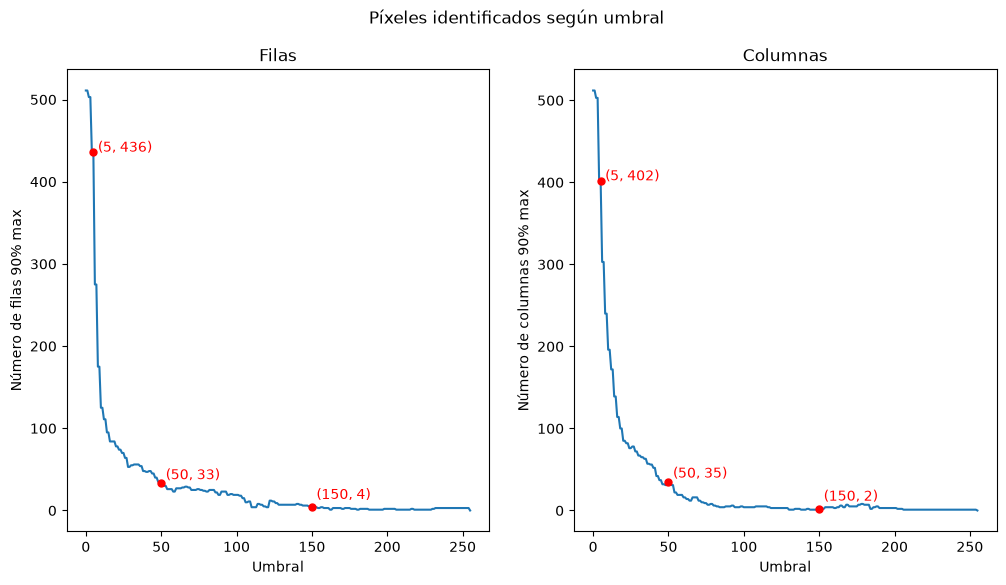

In [114]:
plt.figure(figsize=(12, 6))
plt.suptitle('Píxeles identificados según umbral')

plt.subplot(1, 2, 1)
plot_threshold_curve(threshold_row_stats, 'Filas', 'Umbral', 'Número de filas 90% max')

plt.subplot(1, 2, 2)
plot_threshold_curve(threshold_col_stats, 'Columnas', 'Umbral', 'Número de columnas 90% max')

plt.show()

Con umbrales bajos, casi todos los píxeles son blancos. Esto causa que prácticamente todas las filas y columnas alcancen el 90% del máximo. 
<br><br>
Al aumentar el umbral, va disminuyendo el número de píxeles considerados como blancos, y cada vez menos filas y columnas cumplen la condición `0.9 × recuento[max_idx]`.

Este cambio también se puede representar gráficamente, destacando nuevamente las filas y columnas que cumplen `0.9 × recuento[max_idx]`:

In [115]:
def get_stats(image):
    row_count = row_counts(image)
    max_row_idx = find_max_idx(row_count)
    max90_row_idx = find_max90_idx(row_count, max_row_idx)

    col_count = col_counts(image)
    max_col_idx = find_max_idx(col_count)
    max90_col_idx = find_max90_idx(col_count, max_col_idx)

    return {'row_stats': {'counts': row_count, 'max_idx': max_row_idx, 'max90_idx': max90_row_idx}, 
            'col_stats': {'counts': col_count, 'max_idx': max_col_idx, 'max90_idx': max90_col_idx}}

In [116]:
canny_rgb = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
canny_stats = get_stats(canny)

sobel5 = cv2.threshold(sobel8, 5, 255, cv2.THRESH_BINARY)[1]
sobel5_stats = get_stats(sobel5)

sobel50 = cv2.threshold(sobel8, 50, 255, cv2.THRESH_BINARY)[1]
sobel50_stats = get_stats(sobel50)

sobel150 = cv2.threshold(sobel8, 150, 255, cv2.THRESH_BINARY)[1]
sobel150_stats = get_stats(sobel150)

In [117]:
def show(subplot, image, title):
    subplot.axis('off')
    subplot.imshow(image, cmap='gray')
    subplot.set_title(title)

def draw_lines(image, stats, axis):
    axis_stats = stats[f'{axis}_stats']
    if axis == 'row':
        return row_threshold(image, axis_stats['max_idx'], axis_stats['max90_idx'])
    return col_threshold(image, axis_stats['max_idx'], axis_stats['max90_idx'])

In [118]:
def plot_thresholds_in_image(subplots, image, image_stats, col_title):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    show(subplots[0], image_rgb, col_title)
    show(subplots[1], draw_lines(image_rgb, image_stats, 'row'), f"{col_title} - Filas")
    show(subplots[2], draw_lines(image_rgb, image_stats, 'col'), f"{col_title} - Columnas")

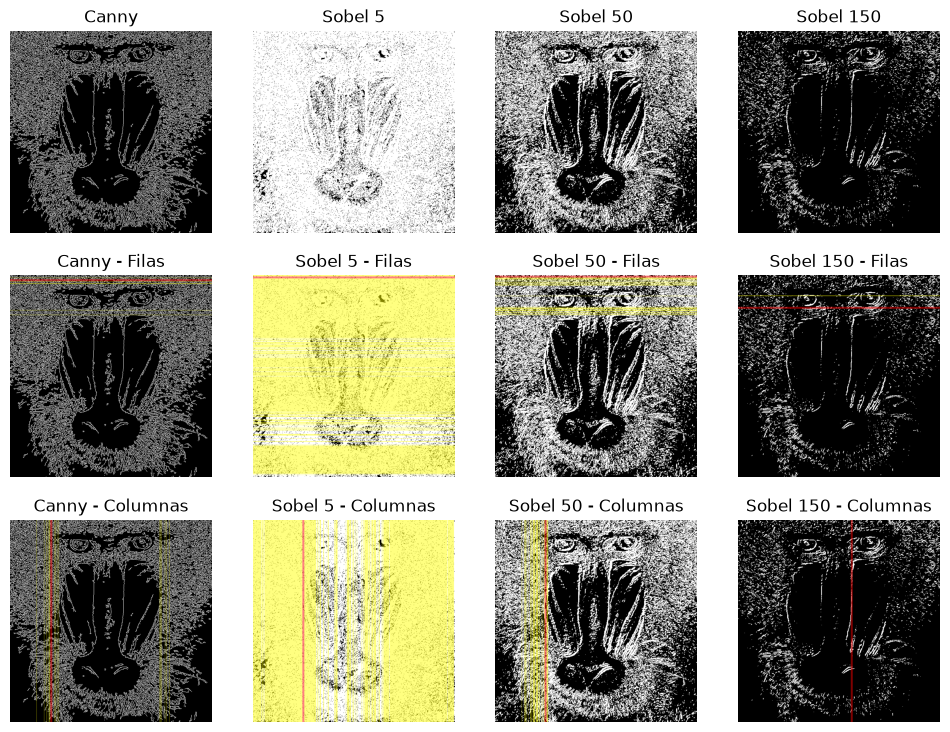

In [119]:
fig, subplots = plt.subplots(3, 4, figsize=(12, 9))

plot_thresholds_in_image(subplots[:, 0], canny, canny_stats, "Canny")
plot_thresholds_in_image(subplots[:, 1], sobel5, sobel5_stats, "Sobel 5")
plot_thresholds_in_image(subplots[:, 2], sobel50, sobel50_stats, "Sobel 50")
plot_thresholds_in_image(subplots[:, 3], sobel150, sobel150_stats, "Sobel 150")

plt.show()

También se puede encontrar el umbral de Sobel que iguala a Canny en número de filas y columnas que alcanzan `0.9 × recuento[max_idx]`:

In [120]:
canny_n_row_90max = canny_stats['row_stats']['max90_idx'].shape[0]
canny_n_col_90max = canny_stats['col_stats']['max90_idx'].shape[0]

sobel_row_threshold = threshold_row_stats.index(canny_n_row_90max)
sobel_col_threshold = threshold_col_stats.index(canny_n_col_90max)

print(f"Canny:\n- Número de filas 90% max: {canny_n_row_90max}\n- Número de columnas 90% max: {canny_n_col_90max}")
print("Sobel:")
print(f"- Número de filas 90% max: {threshold_row_stats[sobel_row_threshold]} (umbral = {sobel_row_threshold})")
print(f"- Número de columnas 90% max: {threshold_col_stats[sobel_col_threshold]} (umbral = {sobel_col_threshold})")

Canny:
- Número de filas 90% max: 7
- Número de columnas 90% max: 19
Sobel:
- Número de filas 90% max: 7 (umbral = 116)
- Número de columnas 90% max: 19 (umbral = 56)


In [121]:
sobel_row_threshold_img = cv2.threshold(sobel8, sobel_row_threshold, 255, cv2.THRESH_BINARY)[1]
sobel_row_threshold_stats = get_stats(sobel_row_threshold_img)

sobel_col_threshold_img = cv2.threshold(sobel8, sobel_col_threshold, 255, cv2.THRESH_BINARY)[1]
sobel_col_threshold_stats = get_stats(sobel_col_threshold_img)

In [122]:
def plot_comparison(subplots, sobel_img, sobel_stats, threshold, axis):
    label = 'Filas' if axis == 'row' else 'Columnas'
    sobel_rgb = cv2.cvtColor(sobel_img, cv2.COLOR_GRAY2RGB)

    show(subplots[0], draw_lines(canny_rgb, canny_stats, axis), f"Canny - {label}")
    show(subplots[1], draw_lines(sobel_rgb, sobel_stats, axis), f"Sobel - {label} (Umbral = {threshold})")
    show(subplots[2], cv2.absdiff(canny, sobel_img), f"Diferencia - {label}")

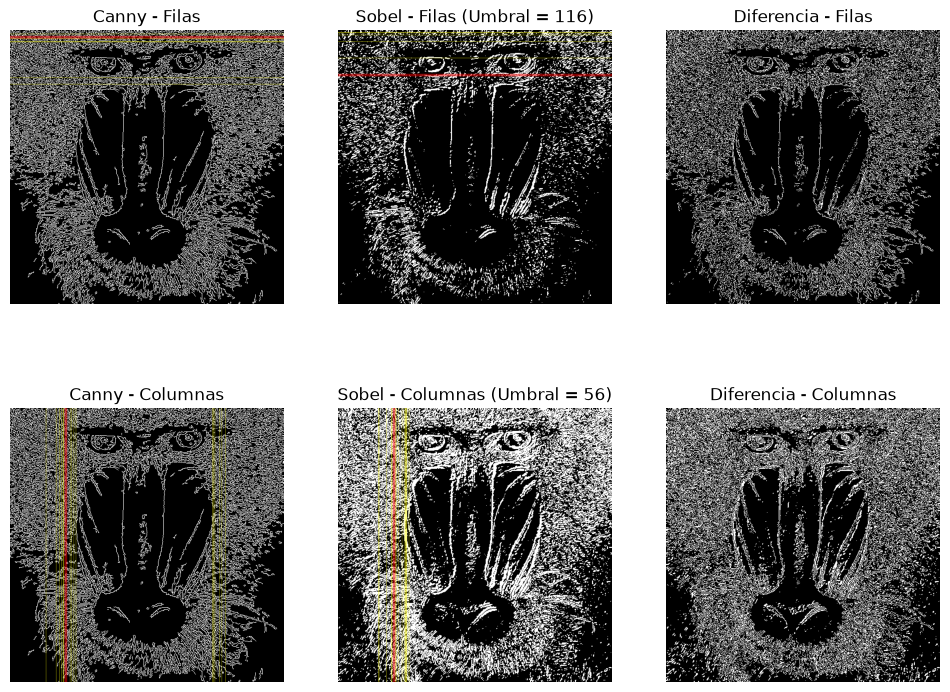

In [123]:
fig, subplots = plt.subplots(2, 3, figsize=(12, 9))

plot_comparison(subplots[0], sobel_row_threshold_img, sobel_row_threshold_stats, sobel_row_threshold, 'row')
plot_comparison(subplots[1], sobel_col_threshold_img, sobel_col_threshold_stats, sobel_col_threshold, 'col')

plt.show()

Aunque las imágenes generadas con Canny y Sobel cuenten con el mismo número de filas y columnas que alcanzan `0.9 × recuento[max_idx]`, estas no coinciden en su posición.
<br><br>
Al mostrar la diferencia entre Canny y Sobel, se detecta que estos dos métodos difieren considerablemente al procesar las texturas. Canny produce bordes muy finos, mientras que Sobel los mantiene más gruesos.

Esta conclusión lleva a reflexionar sobre el valor de umbral que minimiza la diferencia de imágenes entre Canny y Sobel: 

In [124]:
diff_pixels = []

for threshold in range(0, 256):
    sobel_threshold_img = cv2.threshold(sobel8, threshold, 255, cv2.THRESH_BINARY)[1]
    diff_pixels.append(cv2.countNonZero(cv2.absdiff(canny, sobel_threshold_img)))

best_threshold = int(np.argmin(diff_pixels))
best_img = cv2.threshold(sobel8, best_threshold, 255, cv2.THRESH_BINARY)[1]

print(f"- Umbral que minimiza la diferencia: {best_threshold}")


- Umbral que minimiza la diferencia: 134


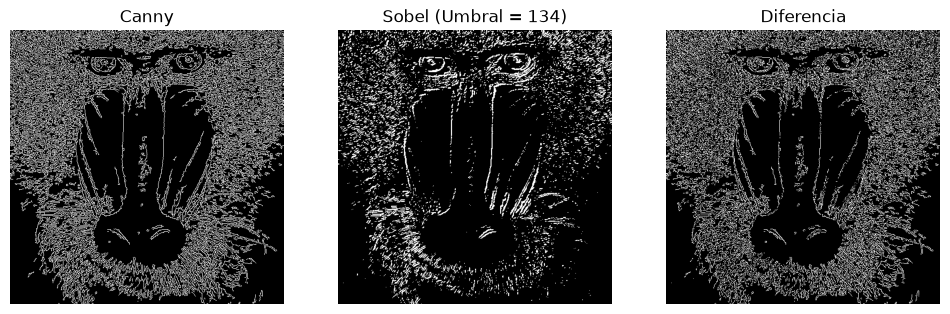

In [125]:
fig, subplots = plt.subplots(1, 3, figsize=(12, 4))

show(subplots[0], canny, "Canny")
show(subplots[1], best_img, f"Sobel (Umbral = {best_threshold})")
show(subplots[2], cv2.absdiff(canny, best_img), "Diferencia")

plt.show()

Se observa que, aun usando el umbral que minimiza la diferencia, la imagen generada por `cv2.absdiff` mantiene un gran número de píxeles blancos. Pocos píxeles de borde coinciden entre los dos métodos, lo que confirma la disparidad en el procesamiento de las imágenes.

### Tarea 3 - Demostraciones con procesamiento de imagen

En esta última tarea, a partir de los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://www.youtube.com/watch?feature=shared&v=GfoqiyB1ndE) y [Virtual air guitar](https://www.youtube.com/watch?feature=shared&v=FIAmyoEpV5c), se han realizado una serie de demostraciones. Estas reinterpretan el procesamiento de la imagen de los vídeos, haciendo uso de sustracción de fotogramas y división entre el modelo y el fondo.

In [2]:
import cv2
import numpy as np

En primer lugar, se ha realizado una separación entre el modelo y el fondo. Una vez realizada la división, se puede reemplazar el fondo por una imagen o por un vídeo:

In [133]:
def separate_objects_background(frame, background_replacement, background_subtractor):
    height, width = frame.shape[:2]
    objects_mask = background_subtractor.apply(frame)
    background_mask = cv2.bitwise_not(objects_mask)

    objects = cv2.bitwise_and(frame, frame, mask=objects_mask)
    background = cv2.bitwise_and(background_replacement, background_replacement, mask=background_mask)

    collage = np.hstack((frame, objects, cv2.add(objects, background)))
    return cv2.resize(collage, (int(width*1.5),int(height/2)), interpolation=cv2.INTER_NEAREST)

In [134]:
def separate_background(video_capture, background_replacement):
    background_subtractor = cv2.createBackgroundSubtractorMOG2(history=2500, varThreshold=160, detectShadows=False)
    width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

    is_video = type(background_replacement) == cv2.VideoCapture

    if not is_video:
        background = cv2.resize(background_replacement, (width, height), interpolation=cv2.INTER_CUBIC)

    while True:
        ret, frame = video_capture.read()

        if is_video:
            video_ret, video_frame = background_replacement.read()
            if not video_ret:
                background_replacement.set(cv2.CAP_PROP_POS_FRAMES, 0)
                video_ret, video_frame = background_replacement.read()
            
            background = cv2.resize(video_frame, (width, height), interpolation=cv2.INTER_CUBIC)

        if ret:
            cv2.imshow('Tarea 3 - Fondo', separate_objects_background(frame, background, background_subtractor))

        if cv2.waitKey(20) == 27:
            break

    video_capture.release()
    if is_video:
        background_replacement.release()
    cv2.destroyAllWindows()

Con estas herramientas, se puede imitar a Homero Simpson, desvaneciéndose en un arbusto:

[![Homer Simpson Arbusto](./exercises/homer-simpson.gif)](https://tenor.com/view/homer-simpson-bush-escape-im-out-gif-10058041)

In [135]:
separate_background(cv2.VideoCapture(0), cv2.imread('exercises/arbusto-image.jpeg'))

O simular estar sobrevolando una ciudad:

[![Ciudad](./exercises/city-gif.gif)](https://gifer.com/en/WBVi)

In [26]:
separate_background(cv2.VideoCapture(0), cv2.VideoCapture('exercises/city-gif.gif'))

Por otro lado, combinando la detección de fondo y la sustracción de fotogramas, se puede recrear [*La creación de Adán*](https://es.wikipedia.org/wiki/La_creaci%C3%B3n_de_Ad%C3%A1n):

[![La creación de Adán](./exercises/la-creacion-de-adan.jpg)](https://www.culturagenial.com/es/cuadro-la-creacion-de-adan-de-miguel-angel/)

Para imitar este fresco, se realizan dos copias del modelo extraído del fondo: una normal y otra rotada 180º. De esta forma, parece que la persona y su reflejo se tienden la mano.
<br><br>
La sustracción de fotogramas permite resaltar el movimiento, envolviendo las manos en un halo de color.

In [143]:
video_capture = cv2.VideoCapture(0)

background_subtractor = cv2.createBackgroundSubtractorMOG2(history=90000, varThreshold=15, detectShadows=False)
width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

painting = cv2.resize(cv2.imread('./exercises/la-creacion-de-adan.jpg'), (width, height), interpolation=cv2.INTER_CUBIC)
painting_background = cv2.resize(cv2.imread('./exercises/la-creacion-de-adan-background.jpg'), (width, height), interpolation=cv2.INTER_CUBIC)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('./exercises/tarea4_2.mp4', fourcc, 20.0, (4 * width, 2*height))

_, frame = video_capture.read()
previous_frame = np.zeros_like(frame)

while(True):
    ret, frame = video_capture.read()

    if ret:
        objects_mask = background_subtractor.apply(frame)
        objects = cv2.bitwise_and(frame, frame, mask=objects_mask)
        objects_mirrored = cv2.add(objects, cv2.rotate(objects, cv2.ROTATE_180))
        
        frame_subtraction = cv2.absdiff(objects_mirrored, previous_frame)
        previous_frame = objects_mirrored

        background_mask = cv2.bitwise_not(cv2.bitwise_or(objects_mask, cv2.rotate(objects_mask, cv2.ROTATE_180)))
        objects_on_painting = cv2.add(objects_mirrored, cv2.bitwise_and(painting_background, painting_background, mask=background_mask))
  
        collage = np.vstack((
                    np.hstack((frame, frame_subtraction, objects_mirrored, cv2.add(objects_mirrored, frame_subtraction))),
                    np.hstack((painting, cv2.add(painting_background, frame_subtraction), objects_on_painting, cv2.add(objects_on_painting, frame_subtraction)))
                  ))
        
        out.write(collage)
        cv2.imshow('Tarea 3 - Fondo + Sustraccion Fotogramas', 
                   cv2.resize(collage, (int(width * 1.75),int(height * 0.75)), interpolation=cv2.INTER_NEAREST))
   
    if cv2.waitKey(20) == 27:
        break
  
out.release()
video_capture.release()
cv2.destroyAllWindows()